In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

In [11]:
gibosn_vs_mp3d = np.array([[46 / 30, 64 / 42], [51 / 39, 62 / 47]]) # according to Table 2 in Savva et al. 2019
print(gibosn_vs_mp3d)

log_data = {'bug': [[500,], [48], [84]],            
            'rl': [[7.50E+07, 2.50E+09, 1.5E+09], [46, 92.0, 87], [64, 97.7, 96]], 
            'slam': [[5.00E+06, 7.50E+07], [4.7 * gibosn_vs_mp3d[1,0], 51], [9.0 * gibosn_vs_mp3d[1,1], 62]],
            'vo': [[14.7E+06, 7.5E+09], [45, 76.6], [59, 96.0]]
           }

# xlb = 'M1 [Mishkin et al 2019]', 'M2&5 [Savva et al 2019]', 'M6 [Wijmans et al 2020]', 'M7 [Ramakrishnan et al 2021]'
# xlb2 = 'M3 [Zhao et al 2021]', 'M4 [Partsey et al 2022]'
xlb = '[Model 1]', '[Model 2 & 5]', '[Model 6]', '[Model 7]'
xlb2 = '[Model 3]', '[Model 4]'

[[1.53333333 1.52380952]
 [1.30769231 1.31914894]]


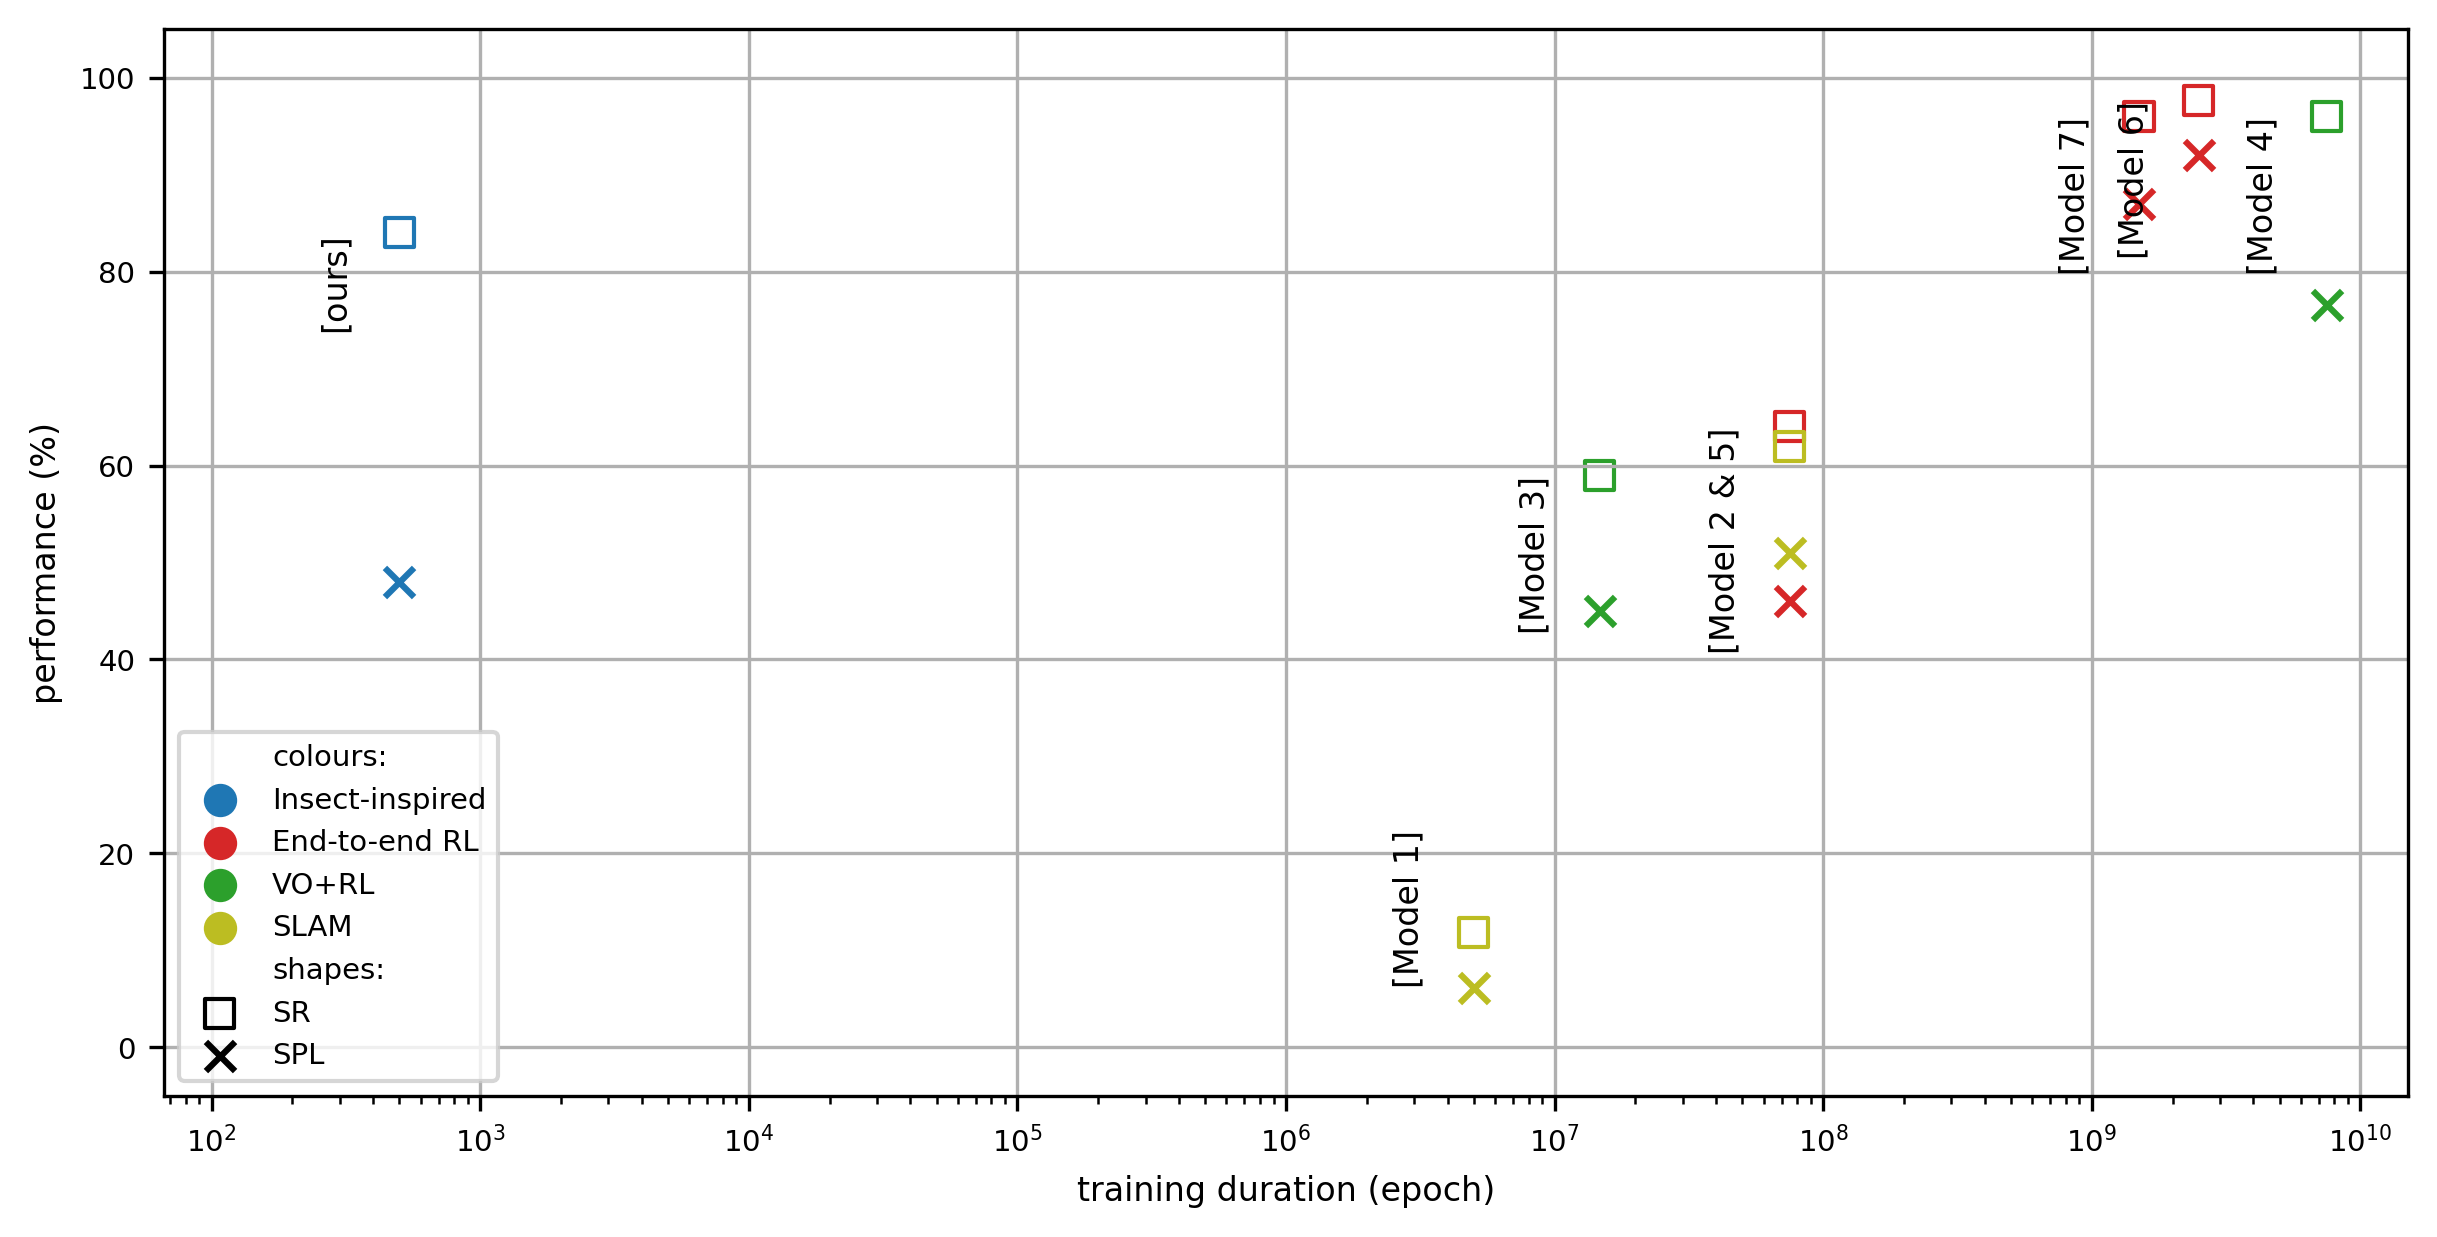

In [12]:
fig, ax = plt.subplots(figsize=(8, 4), sharey=True, dpi=300)


for (step, spl, success), c in zip(log_data.values(), ['tab:blue', 'tab:red', 'tab:olive', 'tab:green']):
    ax.scatter(step, spl, marker = 'x', color=c)
    ax.scatter(step, success, marker = 's', facecolor='none', edgecolor=c)
    # if c == 'tab:blue':
    #     ax.plot(step, spl, color=c, ls='dotted')
    #     ax.plot(step, success, color=c, ls='dashed')

ax.scatter([], [], marker='none', label='colours:')
ax.scatter([], [], marker='o', color='tab:blue', label='Insect-inspired')
ax.scatter([], [], marker='o', color='tab:red', label='End-to-end RL')
ax.scatter([], [], marker='o', color='tab:green', label='VO+RL')
ax.scatter([], [], marker='o', color='tab:olive', label='SLAM')

ax.scatter([], [], marker='none', label='shapes:')
ax.scatter([], [], marker='s', facecolor='none', edgecolor='k', label='SR')
ax.scatter([], [], marker='x', color='k', label='SPL')

# al = 0.5
# ax.axhline(72, label='ablation',
#            color='k', alpha=al, ls='dashed')
# ax.axhline(48, label='baselines',
#            color='k', alpha=al, ls='dotted')

# ax.axhline(28, 
#            color='k', alpha=al, ls='dashed')
# ax.axhline(27, 
#            color='k', alpha=al, ls='dotted')

# ax.set_yticks([0, 20, 27, 28, 40, 48, 60, 72, 80, 100], [0, 20, 'G', '', 40, 'GC', 60, 'GC', 80, 100])

# xxx = np.full(2, 0.8e2)
# ax.scatter(xxx, [27, 48], marker='x', color='k', alpha=al)
# ax.scatter(xxx, [28, 72], marker='s', facecolor='none', edgecolor='k', alpha=al)


ax.legend(ncol=1, loc=0)


ax.set_xscale('log')

# Final plot adjustments
ax.set_ylim(-5, 105)
ax.set_xlim(0.667e2, 1.5e10)
ax.grid()
fig.tight_layout()


ax.set_xlabel('training duration (epoch)')
ax.set_ylabel('performance (%)')


for (step, s1, s2), xl in zip(np.transpose(log_data['slam']), xlb):
    ax.text(step / 2, s1, xl, rotation=90, verticalalignment='bottom')
    break

for (step, s1, s2), xl in zip(np.transpose(log_data['rl']), xlb[1:]):
    ax.text(step / 2, s2, xl, rotation=90, verticalalignment='top')

for (step, s1, s2), xl in zip(np.transpose(log_data['vo']), xlb2):
    ax.text(step / 2, s2, xl, rotation=90, verticalalignment='top')

for (step, s1, s2), xl in zip(np.transpose(log_data['bug']), ['[ours]']):
    ax.text(step / 2, s2, xl, rotation=90, verticalalignment='top')
    
# plt.savefig("baseline.pdf", format="pdf", bbox_inches="tight", dpi=300)

In [13]:
import matplotlib as mpl
mpl.rcParams.update({
    # "font.family": "serif",
    # "font.serif": ["Times New Roman"],
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})

plt.rcParams['lines.markersize'] = 7

In [14]:
# gibosn_vs_mp3d = np.array([[46 / 30, 64 / 42], [51 / 39, 62 / 47]]) # according to Table 2 in Savva et al. 2019
# print(gibosn_vs_mp3d)

# log_data = {'bug': [[500,], [48], [84]],            
#             'rl': [[7.50E+07, 2.50E+09, 1.5E+09], [46, 92.0, 90], [64, 97.7, 100]], 
#             'slam': [[5.00E+06, 7.50E+07], [4.7 * gibosn_vs_mp3d[1,0], 51], [9.0 * gibosn_vs_mp3d[1,1], 62]],
#             'vo': [[14.7E+06, 7.5E+09], [61, 76.6], [79, 96]]
#            }

# xlb = 'M1 [Mishkin et al 2019]', 'M2&5 [Savva et al 2019]', 'M6 [Wijmans et al 2020]', 'M7 [Ramakrishnan et al 2021]'
# xlb2 = 'M3 [Zhao et al 2021]', 'M4 [Partsey et al 2022]'
xlb = 'S1', 'E1\nS2', 'E2\n', 'E3'
xlb2 = 'V1\n', 'V2'

Text(0.5, -0.01, 'Training Frames (#)')

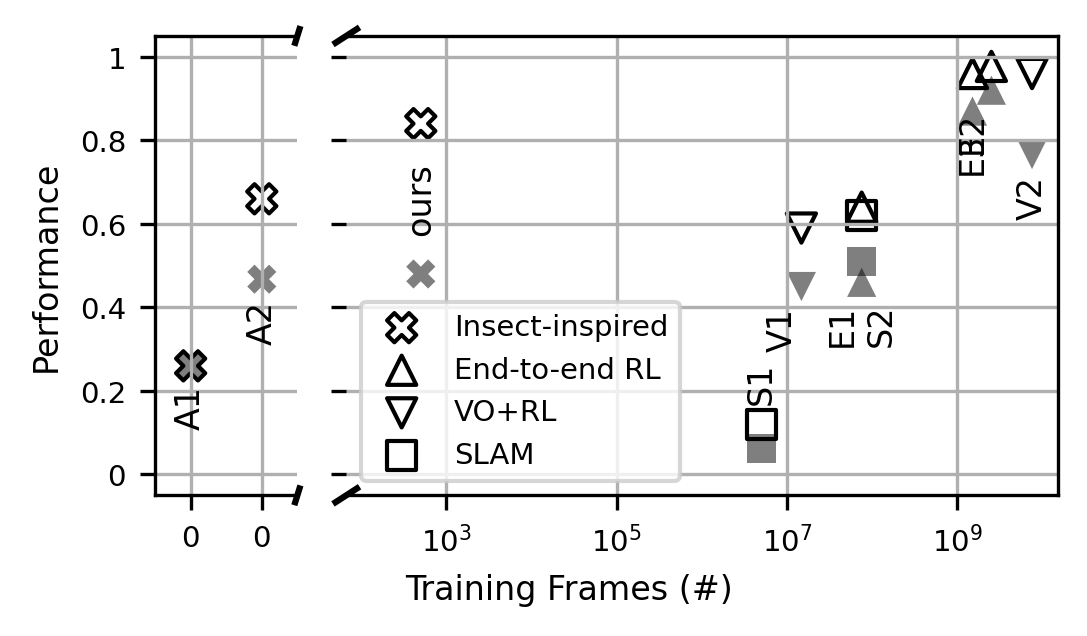

In [15]:
fig, (ax_linear, ax) = plt.subplots(1, 2, figsize=(3.5, 2), sharey=True, gridspec_kw={'width_ratios': [1, 5]}, dpi=300)


ax_linear.scatter(np.arange(2), linear_data[1][:2], marker = 'X', facecolor='k', edgecolor='none', alpha=0.5)
ax_linear.scatter(np.arange(2), linear_data[2][:2], marker = 'X', facecolor='none', edgecolor='k')

for (model_type, (step, spl, success)), c in zip(log_data.items(), ['k', 'tab:blue', 'tab:red', 'tab:green']):
    if model_type == 'bug':
        mk = 'X'
    elif model_type == 'slam':
        mk = 's'
    elif model_type == 'vo':
        mk = 'v'
    else: 
        mk = '^'
    
    ax.scatter(step, spl, marker = mk, facecolor='k', edgecolor='none', alpha=0.5)
    ax.scatter(step, success, marker = mk, facecolor='none', edgecolor='k')
    # [ax.axvline(x, ls='dotted', color='grey') for x in step]

# ax.axvline(linear_data[0], ls='dotted', color='grey')


# ax.scatter([], [], marker='none', label='colours:')
# ax.scatter([], [], marker='o', color='tab:blue', label='Insect-inspired')
ax.scatter([], [], marker='X', fc='none', ec='k', label='Insect-inspired')
ax.scatter([], [], marker='^', fc='none', ec='k', label='End-to-end RL')
ax.scatter([], [], marker='v', fc='none', ec='k', label='VO+RL')
ax.scatter([], [], marker='s', fc='none', ec='k', label='SLAM')

ax_linear.scatter([], [], marker='none', label='shapes:')
ax_linear.scatter([], [], marker='s', facecolor='none', edgecolor='k', label='SR')
ax_linear.scatter([], [], marker='x', color='k', label='SPL')



ax_linear.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xscale('log')
for a in (ax_linear, ax):
    a.grid()
    # a.axhline(log_data['bug'][1], ls='dotted', color='grey')
    # a.axhline(log_data['bug'][2], ls='dotted', color='grey')




# Add a break in the axes
d = 0.015
kwargs = dict(transform=ax_linear.transAxes, color='k', clip_on=False)
ax_linear.plot((1-d, 1+d), (-d, +d), **kwargs)
ax_linear.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax.transAxes)
ax.plot((-d, +d), (-d, +d), **kwargs)
ax.plot((-d, +d), (1-d, 1+d), **kwargs)

# Final plot adjustments
ax.set_ylim(-5, 105)
ax.set_yticks(np.arange(0, 101, 20), [0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_xlim(6.6666e1, 1.5e10)
fig.tight_layout()

ax_linear.set_xlim(-0.5, 1.5)
ax_linear.set_xticks([0, 1], [0, 0])

ax_linear.set_ylabel('Performance')

for (step, s1, s2), xl in zip(np.transpose(log_data['bug']), ['ours']):
    ax.text(step, (s1 + s2)/2, xl, rotation=90, verticalalignment='center', horizontalalignment='center')

for (step, s1, s2), xl in zip(np.transpose(log_data['slam']), xlb):
    ax.text(step, s2 + 5, xl, rotation=90, verticalalignment='bottom', horizontalalignment='center')
    break
    
for (step, s1, s2), xl in zip(np.transpose(log_data['rl']), xlb[1:]):
    ax.text(step, s1 - 5, xl, rotation=90, verticalalignment='top', horizontalalignment='center')

for (step, s1, s2), xl in zip(np.transpose(log_data['vo']), xlb2):
    ax.text(step, s1 - 5, xl, rotation=90, verticalalignment='top', horizontalalignment='center')

for (step, s1, s2), xl in zip(np.transpose(linear_data)[:2], ['A1', 'A2']):
    # if step == 0:
    #     ax_linear.text(step, s2 + 5, xl, rotation=90, verticalalignment='bottom', horizontalalignment='center')
    # else:
    ax_linear.text(step, s1 - 5, xl, rotation=90, verticalalignment='top', horizontalalignment='center')

ax.legend(loc=0, ncols=1)
# ax_linear.legend(loc=2, ncols=1)
fig.text(0.5, -0.01, 'Training Frames (#)', ha='center')
    
# plt.savefig("baseline.pdf", format="pdf", bbox_inches="tight", dpi=300)

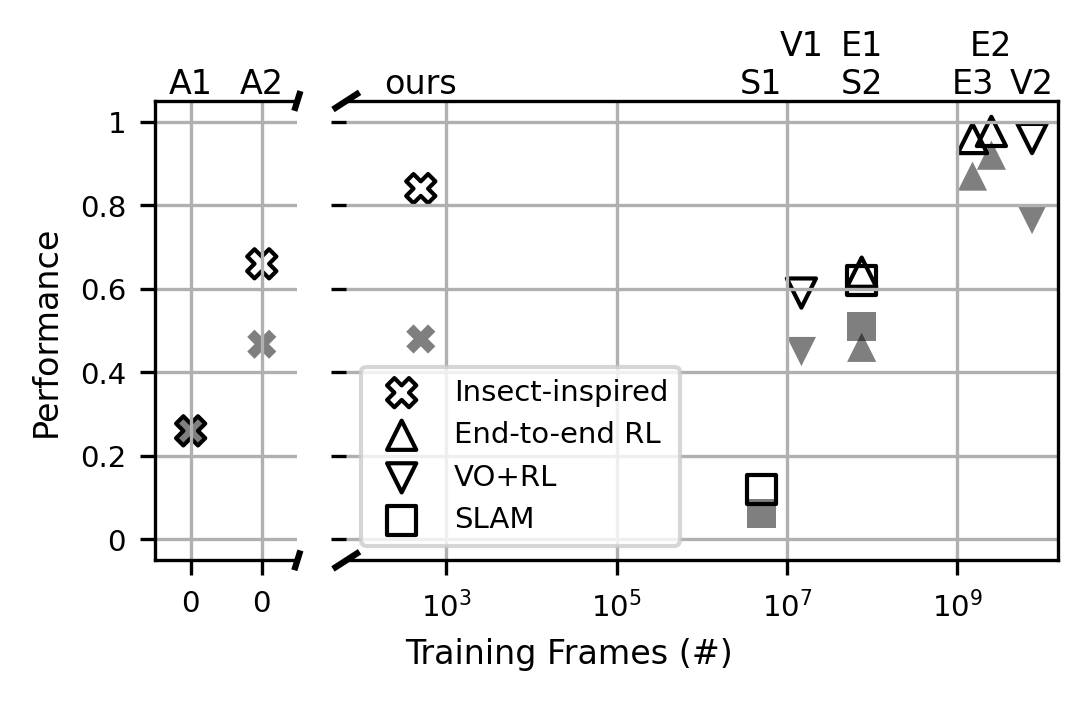

In [16]:
fig, (ax_linear, ax) = plt.subplots(1, 2, figsize=(3.5, 2), sharey=True, gridspec_kw={'width_ratios': [1, 5]}, dpi=300)


ax_linear.scatter(np.arange(2), linear_data[1][:2], marker = 'X', facecolor='k', edgecolor='none', alpha=0.5)
ax_linear.scatter(np.arange(2), linear_data[2][:2], marker = 'X', facecolor='none', edgecolor='k')

for (model_type, (step, spl, success)), c in zip(log_data.items(), ['k', 'tab:blue', 'tab:red', 'tab:green']):
    if model_type == 'bug':
        mk = 'X'
    elif model_type == 'slam':
        mk = 's'
    elif model_type == 'vo':
        mk = 'v'
    else: 
        mk = '^'
    
    ax.scatter(step, spl, marker = mk, facecolor='k', edgecolor='none', alpha=0.5)
    ax.scatter(step, success, marker = mk, facecolor='none', edgecolor='k')
    # [ax.axvline(x, ls='dotted', color='grey') for x in step]

# ax.axvline(linear_data[0], ls='dotted', color='grey')


# ax.scatter([], [], marker='none', label='colours:')
# ax.scatter([], [], marker='o', color='tab:blue', label='Insect-inspired')
ax.scatter([], [], marker='X', fc='none', ec='k', label='Insect-inspired')
ax.scatter([], [], marker='^', fc='none', ec='k', label='End-to-end RL')
ax.scatter([], [], marker='v', fc='none', ec='k', label='VO+RL')
ax.scatter([], [], marker='s', fc='none', ec='k', label='SLAM')

ax_linear.scatter([], [], marker='none', label='shapes:')
ax_linear.scatter([], [], marker='s', facecolor='none', edgecolor='k', label='SR')
ax_linear.scatter([], [], marker='x', color='k', label='SPL')



ax_linear.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xscale('log')
for a in (ax_linear, ax):
    a.grid()
    # a.axhline(log_data['bug'][1], ls='dotted', color='grey')
    # a.axhline(log_data['bug'][2], ls='dotted', color='grey')




# Add a break in the axes
d = 0.015
kwargs = dict(transform=ax_linear.transAxes, color='k', clip_on=False)
ax_linear.plot((1-d, 1+d), (-d, +d), **kwargs)
ax_linear.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

kwargs.update(transform=ax.transAxes)
ax.plot((-d, +d), (-d, +d), **kwargs)
ax.plot((-d, +d), (1-d, 1+d), **kwargs)

# Final plot adjustments
ax.set_ylim(-5, 105)
ax.set_yticks(np.arange(0, 101, 20), [0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_xlim(6.6666e1, 1.5e10)
fig.tight_layout()

ax_linear.set_xlim(-0.5, 1.5)
ax_linear.set_xticks([0, 1], [0, 0])

ax_linear.set_ylabel('Performance')

texty = 105

for (step, s1, s2), xl in zip(np.transpose(log_data['bug']), ['ours']):
    ax.text(step, texty, xl, verticalalignment='bottom', horizontalalignment='center')

for (step, s1, s2), xl in zip(np.transpose(log_data['slam']), xlb):
    ax.text(step, texty, xl, verticalalignment='bottom', horizontalalignment='center')
    break
    
for (step, s1, s2), xl in zip(np.transpose(log_data['rl']), xlb[1:]):
    ax.text(step, texty, xl, verticalalignment='bottom', horizontalalignment='center')

for (step, s1, s2), xl in zip(np.transpose(log_data['vo']), xlb2):
    ax.text(step, texty, xl, verticalalignment='bottom', horizontalalignment='center')

for (step, s1, s2), xl in zip(np.transpose(linear_data)[:2], ['A1', 'A2']):
    # if step == 0:
    #     ax_linear.text(step, s2 + 5, xl, rotation=90, verticalalignment='bottom', horizontalalignment='center')
    # else:
    ax_linear.text(step, texty, xl, verticalalignment='bottom', horizontalalignment='center')

ax.legend(loc=0, ncols=1)
# ax_linear.legend(loc=2, ncols=1)
fig.text(0.5, -0.01, 'Training Frames (#)', ha='center')
    
plt.savefig("baseline.pdf", format="pdf", bbox_inches="tight", dpi=300)